# Phân rã STL — profile day-of-week & regime Tết Nguyên Đán 2026

**Mục tiêu:** Ước lượng **thành phần mùa vụ chu kỳ 7 ngày** trên chuỗi thời gian lượt **explicit contact** (login), rồi so sánh **profile DOW** giữa **baseline** và **cửa sổ nghỉ Tết** (không lọc cả tháng 2).

| Khái niệm | Định nghĩa |
|----------|------------|
| Biến quan sát $y_t$ | Số event `view_phone`, `contact_chat`, `contact_zalo`, `contact_sms`, `is_login = login` |
| Phân rã | STL($y_t$, `period=7`, `robust=True`) → trend, seasonal, residual |
| Profile DOW | $\bar{S}_d = \mathbb{E}[S_t \mid \mathrm{dow}(t)=d]$ trên tập ngày được chọn |
| **Treatment (Tết)** | **12 ngày** kết thúc **22/02**, mở rộng về trước Mùng 1 → **2026-02-11 → 2026-02-22** (Mùng 1 = 17/02) |
| **Heatmap liên hệ** | Lưu lượng explicit contact (`view_phone`, `contact_chat`, `contact_zalo`, `contact_sms`, login) theo **DOW × giờ** — toàn cửa sổ EDA |
| **Baseline** | Mọi ngày trong cửa sổ EDA **không** thuộc treatment |

**Export:** không bắt buộc — notebook chạy độc lập trên `fact_user_events`.

**Kernel:** chọn **Datathon (env)** hoặc Python đã cài `requirements-eda.txt` (gồm `statsmodels`). Cell đầu tự `pip install` nếu thiếu package trong kernel hiện tại.

---

## Phân rã STL (chu kỳ 7 ngày): explicit contact theo day-of-week — baseline vs. regime Tết

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Coverage:** `2025-11-09` → `2026-04-09` · $n_{baseline}$ = 140 ngày · $n_{Tết}$ = 12 ngày (`2026-02-11`–`2026-02-22`)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Khung 8h–16h:** trung bình **60.2%** lưu lượng explicit/ngày ($n=152$ ngày) · **60.9%** tổng sự kiện toàn kỳ.

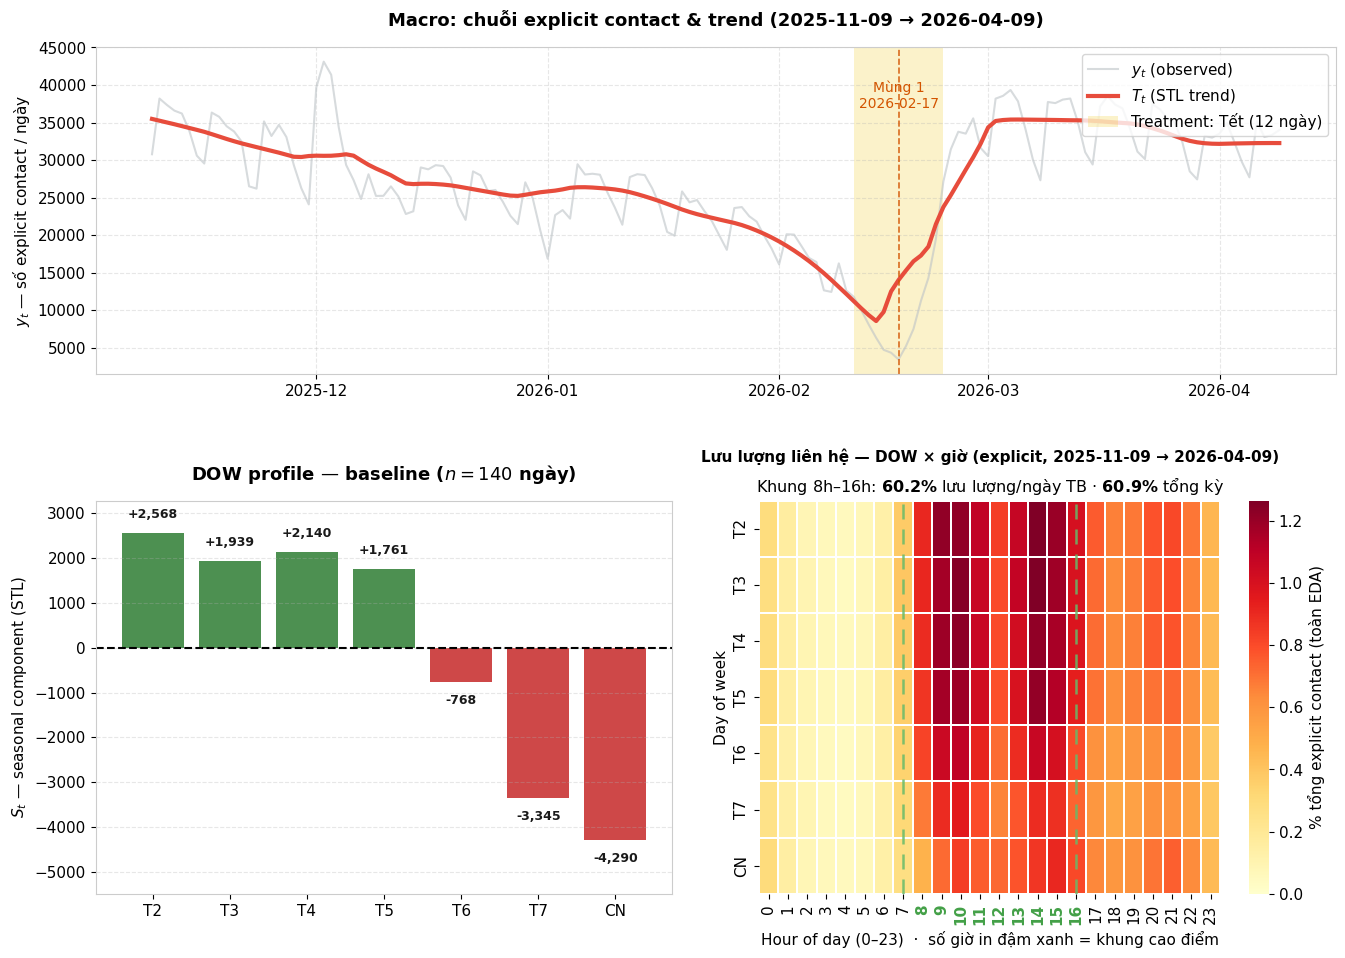

### Kết luận định lượng

,layer,n_days_or_events,peak_signal,spread_metric
0,baseline_STL_seasonal,140,T2,6857.141375
1,full_period_explicit_heatmap,4126786,T3 @ 14h,1.220926


hour,9,10,11,12,13,14,15,16,17,18,19,20,21
dow,,,,,,,,,,,,,
T2,1.22,1.22,1.09,0.84,1.07,1.26,1.20,1.01,0.76,0.67,0.68,0.78,0.81
T3,1.17,1.25,1.06,0.80,1.08,1.27,1.18,1.00,0.72,0.64,0.67,0.77,0.79
T4,1.19,1.23,1.06,0.80,1.03,1.22,1.16,0.98,0.72,0.64,0.66,0.76,0.78
T5,1.17,1.19,1.03,0.79,0.99,1.21,1.13,0.93,0.70,0.63,0.66,0.70,0.73
T6,1.05,1.09,0.92,0.71,0.89,1.06,1.01,0.80,0.61,0.55,0.58,0.62,0.66
T7,0.90,0.95,0.80,0.66,0.77,0.89,0.88,0.73,0.59,0.52,0.54,0.61,0.61
CN,0.72,0.84,0.75,0.72,0.78,0.86,0.90,0.81,0.65,0.59,0.61,0.70,0.75


### Diễn giải cho mô hình gợi ý (recommender / demand)

- Macro: $T_t$ giảm mạnh quanh cửa sổ treatment Tết → structural break / demand shock; không nên extrapolate trend pre-holiday sang ngày trong Tết.
- Baseline (STL $S_t$): peak DOW = T2; cuối tuần vs mid-week ≈ -5085 trên scale seasonal.
- Liên hệ explicit (toàn EDA): peak tại **T3 14h** (1.27% tổng); chỉ view_phone, contact_chat, contact_zalo, contact_sms; heatmap prior `hour×dow`; Tết (12 ngày) chỉ overlay trên macro.


In [1]:
%matplotlib inline
from __future__ import annotations

import subprocess
import sys
import warnings
from pathlib import Path

try:
    from statsmodels.tsa.seasonal import STL
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels>=0.14"])
    from statsmodels.tsa.seasonal import STL

import duckdb
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#cccccc",
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
})

DATA_ROOT = Path.cwd().resolve()
for name in ("fact_user_events",):
    if not (DATA_ROOT / name).exists():
        raise FileNotFoundError(f"Thiếu `{name}` trong {DATA_ROOT}")

EVENTS_GLOB = str(DATA_ROOT / "fact_user_events" / "*.parquet")
LOGIN_WHERE = "is_login = 'login'"
EXPLICIT_TYPES = ("view_phone", "contact_chat", "contact_zalo", "contact_sms")
EXPLICIT_SQL = ", ".join(repr(x) for x in EXPLICIT_TYPES)
# Chỉ đếm event có event_type ∈ EXPLICIT_TYPES (mỗi event = 1 → count ≥ 1)
EXPLICIT_EVENT_WHERE = f"event_type IN ({EXPLICIT_SQL})"

CATEGORIES = (1010, 1020, 1030, 1040, 1050)
CAT_SQL = ", ".join(str(c) for c in CATEGORIES)

# Treatment Tết: 12 ngày, kéo dài về trước Mùng 1 (kết thúc giữ ngày cuối nghỉ lễ 22/02)
TET_MUNG1 = pd.Timestamp("2026-02-17")
TET_HOLIDAY_END = pd.Timestamp("2026-02-22")
TET_TREATMENT_DAYS = 12
TET_HOLIDAY_START = TET_HOLIDAY_END - pd.Timedelta(days=TET_TREATMENT_DAYS - 1)  # 2026-02-11

DOW_LABELS = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]  # pandas dayofweek: 0=Mon … 6=Sun
DOW_ORDER = list(range(7))
HOUR_ORDER = list(range(24))

con = duckdb.connect(":memory:")
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

display(Markdown("---"))
display(
    Markdown(
        "## Phân rã STL (chu kỳ 7 ngày): explicit contact theo day-of-week — baseline vs. regime Tết"
    )
)

try:
    # ------------------------------------------------------------------
    # 1. Chuỗi thời gian ngày: y_t = count(explicit contact | login)
    # ------------------------------------------------------------------
    daily_events = con.execute(
        f"""
        SELECT CAST(date AS DATE) AS date,
               COUNT(*)::BIGINT AS y_explicit
        FROM read_parquet('{EVENTS_GLOB}')
        WHERE {LOGIN_WHERE}
          AND {EXPLICIT_EVENT_WHERE}
          AND category IN ({CAT_SQL})
        GROUP BY 1
        ORDER BY 1
        """
    ).df()

    df_plot = daily_events.copy()
    df_plot["date"] = pd.to_datetime(df_plot["date"])
    t_min, t_max = df_plot["date"].min(), df_plot["date"].max()

    ts = (
        df_plot.set_index("date")["y_explicit"]
        .asfreq("D")
        .interpolate(method="time")
    )

    mask_tet = (ts.index >= TET_HOLIDAY_START) & (ts.index <= TET_HOLIDAY_END)
    mask_baseline = ~mask_tet
    n_tet_days = int(mask_tet.sum())
    n_baseline_days = int(mask_baseline.sum())

    display(
        Markdown(
            f"**Coverage:** `{t_min.date()}` → `{t_max.date()}` · "
            f"$n_{{baseline}}$ = {n_baseline_days} ngày · "
            f"$n_{{Tết}}$ = {n_tet_days} ngày "
            f"(`{TET_HOLIDAY_START.date()}`–`{TET_HOLIDAY_END.date()}`)"
        )
    )

    # ------------------------------------------------------------------
    # 2. STL: seasonal period = 7 (weekly), robust=True
    # ------------------------------------------------------------------
    stl_fit = STL(ts, period=7, robust=True).fit()
    seasonal = pd.Series(stl_fit.seasonal, index=ts.index, name="S_t")
    trend = pd.Series(stl_fit.trend, index=ts.index, name="T_t")

    def dow_profile(s: pd.Series) -> pd.Series:
        return s.groupby(s.index.dayofweek).mean().reindex(range(7))

    prof_baseline = dow_profile(seasonal[mask_baseline])

    y_pad = 1.28
    y_max = prof_baseline.max() * y_pad
    y_min = prof_baseline.min() * y_pad
    # Khung giờ cao điểm trên heatmap (explicit 8h–16h)
    PEAK_HOURS = list(range(8, 17))
    PEAK_COLOR = "#66BB6A"  # xanh lá sáng (viền khung giờ)
    PEAK_TICK = "#43A047"   # xanh lá đậm vừa (tick 8h–16h, vẫn đọc được)

    # Lưu lượng explicit contact — DOW × hour, toàn cửa sổ EDA
    traffic_all = con.execute(
        f"""
        SELECT
            (EXTRACT('dow' FROM event_ts)::INTEGER + 6) % 7 AS dow_mon0,
            EXTRACT('hour' FROM event_ts)::INTEGER AS hour,
            COUNT(*)::BIGINT AS n_explicit
        FROM read_parquet('{EVENTS_GLOB}')
        WHERE {LOGIN_WHERE}
          AND {EXPLICIT_EVENT_WHERE}
          AND category IN ({CAT_SQL})
        GROUP BY 1, 2
        """
    ).df()

    heat_all = (
        traffic_all.pivot(index="dow_mon0", columns="hour", values="n_explicit")
        .reindex(index=DOW_ORDER, columns=HOUR_ORDER)
        .fillna(0)
    )
    heat_all.index = DOW_LABELS
    heat_all_share = heat_all / heat_all.values.sum() * 100.0

    peak_hour_cols = [h for h in PEAK_HOURS if h in heat_all.columns]
    peak_share_total = 100.0 * heat_all[peak_hour_cols].values.sum() / heat_all.values.sum()

    daily_peak_stats = con.execute(
        f"""
        WITH hourly AS (
            SELECT CAST(date AS DATE) AS d,
                   EXTRACT('hour' FROM event_ts)::INTEGER AS hod,
                   COUNT(*)::BIGINT AS n
            FROM read_parquet('{EVENTS_GLOB}')
            WHERE {LOGIN_WHERE}
              AND {EXPLICIT_EVENT_WHERE}
              AND category IN ({CAT_SQL})
            GROUP BY 1, 2
        ),
        day_agg AS (
            SELECT d,
                   SUM(n)::DOUBLE AS n_day,
                   SUM(CASE WHEN hod BETWEEN 8 AND 16 THEN n ELSE 0 END)::DOUBLE AS n_peak
            FROM hourly
            GROUP BY 1
        )
        SELECT AVG(100.0 * n_peak / NULLIF(n_day, 0)) AS avg_daily_pct,
               COUNT(*)::INTEGER AS n_days
        FROM day_agg
        """
    ).fetchone()
    peak_share_daily_avg = float(daily_peak_stats[0] or 0.0)
    n_days_peak = int(daily_peak_stats[1] or 0)

    display(
        Markdown(
            f"**Khung 8h–16h:** trung bình **{peak_share_daily_avg:.1f}%** lưu lượng explicit/ngày "
            f"($n={n_days_peak}$ ngày) · **{peak_share_total:.1f}%** tổng sự kiện toàn kỳ."
        )
    )

    # ------------------------------------------------------------------
    # 3. Dashboard: macro (observed + trend) + DOW profiles
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(16, 11), dpi=100)
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.35, wspace=0.15)

    ax_macro = fig.add_subplot(gs[0, :])
    ax_macro.plot(ts.index, ts.values, color="#bdc3c7", alpha=0.6, label="$y_t$ (observed)")
    ax_macro.plot(trend.index, trend.values, color="#e74c3c", lw=3, label="$T_t$ (STL trend)")
    ax_macro.axvspan(
        TET_HOLIDAY_START,
        TET_HOLIDAY_END + pd.Timedelta(days=1),
        color="#f1c40f",
        alpha=0.22,
        lw=0,
        label=f"Treatment: Tết ({TET_TREATMENT_DAYS} ngày)",
    )
    ax_macro.axvline(TET_MUNG1, color="#d35400", ls="--", lw=1.2, alpha=0.85)
    ax_macro.set_title(
        f"Macro: chuỗi explicit contact & trend ({t_min:%Y-%m-%d} → {t_max:%Y-%m-%d})",
        pad=15,
    )
    ax_macro.set_ylabel("$y_t$ — số explicit contact / ngày")
    ax_macro.grid(axis="both", linestyle="--")
    ax_macro.legend(loc="upper right")
    y_top = ax_macro.get_ylim()[1]
    ax_macro.text(
        TET_MUNG1,
        y_top * 0.82,
        "Mùng 1\n2026-02-17",
        ha="center",
        color="#d35400",
        fontsize=10,
    )

    def bar_dow(ax, prof: pd.Series, title: str, pos_color: str, neg_color: str):
        colors = [pos_color if v >= 0 else neg_color for v in prof.values]
        bars = ax.bar(DOW_LABELS, prof.values, color=colors, alpha=0.85)
        ax.axhline(0, color="black", lw=1.5, linestyle="--")
        label_pad = (y_max - y_min) * 0.03
        for bar, v in zip(bars, prof.values):
            if v >= 0:
                y_txt, va = v + label_pad, "bottom"
            else:
                y_txt, va = v - label_pad, "top"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y_txt,
                f"{v:+,.0f}",
                ha="center",
                va=va,
                fontsize=9,
                fontweight="bold",
                color="#1a1a1a",
            )
        ax.set_title(title, pad=15)
        ax.set_ylabel("$S_t$ — seasonal component (STL)")
        ax.set_ylim(y_min, y_max)
        ax.grid(axis="y", linestyle="--")

    ax_base = fig.add_subplot(gs[1, 0])
    bar_dow(
        ax_base,
        prof_baseline,
        f"DOW profile — baseline ($n={n_baseline_days}$ ngày)",
        "#2E7D32",
        "#C62828",
    )

    ax_traffic = fig.add_subplot(gs[1, 1])
    sns.heatmap(
        heat_all_share,
        ax=ax_traffic,
        cmap="YlOrRd",
        linewidths=0.3,
        linecolor="white",
        cbar_kws={"label": "% tổng explicit contact (toàn EDA)"},
        vmin=0,
    )
    # Khung 8h–16h — viền xanh lá + tick giờ (không nhãn chồng title)
    g0, g1 = min(PEAK_HOURS), max(PEAK_HOURS)
    for x in (g0 - 0.5, g1 + 0.5):
        ax_traffic.axvline(
            x=x,
            color=PEAK_COLOR,
            linewidth=1.8,
            linestyle=(0, (6, 4)),
            alpha=0.85,
            zorder=10,
        )
    for tick in ax_traffic.get_xticklabels():
        try:
            h = int(tick.get_text())
        except ValueError:
            continue
        if g0 <= h <= g1:
            tick.set_color(PEAK_TICK)
            tick.set_fontweight("bold")
    ax_traffic.set_title(
        f"Lưu lượng liên hệ — DOW × giờ (explicit, {t_min:%Y-%m-%d} → {t_max:%Y-%m-%d})",
        pad=28,
        fontsize=11,
    )
    ax_traffic.text(
        0.5,
        1.01,
        f"Khung {g0}h–{g1}h: "
        f"$\\mathbf{{{peak_share_daily_avg:.1f}\\%}}$ lưu lượng/ngày TB · "
        f"$\\mathbf{{{peak_share_total:.1f}\\%}}$ tổng kỳ",
        transform=ax_traffic.transAxes,
        ha="center",
        va="bottom",
        fontsize=11.5,
    )
    ax_traffic.set_xlabel("Hour of day (0–23)  ·  số giờ in đậm xanh = khung cao điểm")
    ax_traffic.set_ylabel("Day of week")
    ax_traffic.tick_params(axis="x", pad=4)

    plt.show()

    # ------------------------------------------------------------------
    # 4. Số liệu tóm tắt (định lượng)
    # ------------------------------------------------------------------
    peak_base = DOW_LABELS[int(prof_baseline.idxmax())]
    weekend_base = float(prof_baseline.loc[[5, 6]].mean())
    midweek_base = float(prof_baseline.loc[1:4].mean())

    peak_cell = heat_all_share.stack().idxmax()
    peak_dow, peak_hour = peak_cell[0], int(peak_cell[1])
    total_pv_all = int(heat_all.values.sum())

    display(Markdown("### Kết luận định lượng"))
    summary = pd.DataFrame(
        {
            "layer": ["baseline_STL_seasonal", "full_period_explicit_heatmap"],
            "n_days_or_events": [n_baseline_days, total_pv_all],
            "peak_signal": [peak_base, f"{peak_dow} @ {peak_hour:02d}h"],
            "spread_metric": [
                float(prof_baseline.max() - prof_baseline.min()),
                float(heat_all_share.to_numpy().max() - heat_all_share.to_numpy().min()),
            ],
        }
    )
    display(summary)
    display(
        heat_all_share.round(2)
        .loc[:, [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]]
        .rename_axis("dow", axis=0)
        .rename_axis("hour", axis=1)
    )

    display(Markdown("### Diễn giải cho mô hình gợi ý (recommender / demand)"))
    print(
        "- Macro: $T_t$ giảm mạnh quanh cửa sổ treatment Tết → structural break / demand shock; "
        "không nên extrapolate trend pre-holiday sang ngày trong Tết."
    )
    print(
        f"- Baseline (STL $S_t$): peak DOW = {peak_base}; cuối tuần vs mid-week "
        f"≈ {weekend_base - midweek_base:+.0f} trên scale seasonal."
    )
    print(
        f"- Liên hệ explicit (toàn EDA): peak tại **{peak_dow} {peak_hour:02d}h** "
        f"({heat_all_share.loc[peak_dow, peak_hour]:.2f}% tổng); "
        f"chỉ {', '.join(EXPLICIT_TYPES)}; heatmap prior `hour×dow`; "
        f"Tết ({TET_TREATMENT_DAYS} ngày) chỉ overlay trên macro."
    )

except Exception as e:
    import traceback

    print(f"Pipeline error: {e}")
    traceback.print_exc()
finally:
    con.close()


## Overview hệ thống: demand-side vs supply-side (full category)

Ước lượng overlap `user_id` (event) vs `seller_id` (listing) trên **toàn bộ BĐS** (1010–1050).

| Cell | Việc cần làm |
|------|----------------|
| **Imports** | Package + đường dẫn — chạy nhanh, không quét data |
| **Scan (1 lần)** | PyArrow scan + cache pickle — **chỉ chạy lại khi cần refresh** |
| **Viz** | Pie + bảng metrics — dùng biến/cache, **không quét lại** |

In [ ]:
# --- Cell: Imports & cấu hình (không quét data) ---
import subprocess
import sys
from pathlib import Path

import pandas as pd

try:
    import plotly.express as px
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly>=5.0"])
    import plotly.express as px

DATA_ROOT = Path.cwd().resolve()
EVENTS_DIR = DATA_ROOT / "fact_user_events"
DIM_DIR = DATA_ROOT / "dim_listing"
for p in (EVENTS_DIR, DIM_DIR):
    if not p.exists():
        raise FileNotFoundError(f"Thiếu thư mục: {p}")

# Full category BĐS (overview hệ thống)
CATEGORIES = (1010, 1020, 1030, 1040, 1050)
SCOPE_LABEL = "Toàn hệ thống BĐS (1010–1050)"

CACHE_DIR = DATA_ROOT / "outputs" / "_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
ROLE_CACHE_PATH = CACHE_DIR / "role_overlap_full_categories.pkl"

# False = dùng cache nếu có; True = quét lại parquet
REFRESH_ROLE_SCAN = False

print("Imports OK ·", SCOPE_LABEL)
print("Cache:", ROLE_CACHE_PATH)
print("REFRESH_ROLE_SCAN =", REFRESH_ROLE_SCAN)

Imports OK · Toàn hệ thống BĐS (1010–1050)
Cache: /Users/dothinh_3112/Downloads/Datathon_Data/outputs/_cache/role_overlap_full_categories.pkl
REFRESH_ROLE_SCAN = False


In [ ]:
# --- Cell: Scan 1 lần (PyArrow) — chạy lại chỉ khi REFRESH_ROLE_SCAN = True ---
import gc
import pickle
import time

import pyarrow.compute as pc
import pyarrow.dataset as ds
from IPython.display import Markdown, display

t0 = time.perf_counter()
cat_filter = pc.field("category").isin(list(CATEGORIES))

if not REFRESH_ROLE_SCAN and ROLE_CACHE_PATH.exists():
    print("Load cache …", ROLE_CACHE_PATH.name)
    ROLE_OVERVIEW = pickle.loads(ROLE_CACHE_PATH.read_bytes())
else:
    print("Scan parquet (full category) …")
    ev_ds = ds.dataset(str(EVENTS_DIR), format="parquet")
    demand_tbl = ev_ds.to_table(filter=cat_filter, columns=["user_id"])
    U_DEMAND = {u for u in demand_tbl.column("user_id").to_pylist() if u is not None}
    del demand_tbl
    gc.collect()

    dim_ds = ds.dataset(str(DIM_DIR), format="parquet")
    supply_tbl = dim_ds.to_table(filter=cat_filter, columns=["seller_id"])
    U_SUPPLY = {s for s in supply_tbl.column("seller_id").to_pylist() if s is not None}
    del supply_tbl
    gc.collect()

    U_OVERLAP = U_DEMAND & U_SUPPLY
    n_demand, n_supply, n_overlap = len(U_DEMAND), len(U_SUPPLY), len(U_OVERLAP)
    union_size = len(U_DEMAND | U_SUPPLY)

    ROLE_OVERVIEW = {
        "scope": SCOPE_LABEL,
        "categories": list(CATEGORIES),
        "n_demand": n_demand,
        "n_supply": n_supply,
        "n_overlap": n_overlap,
        "n_demand_only": n_demand - n_overlap,
        "n_supply_only": n_supply - n_overlap,
        "union_size": union_size,
        "role_df": pd.DataFrame(
            {
                "role_segment": ["demand_only", "supply_only", "dual_role_overlap"],
                "label_vi": [
                    "Chỉ demand-side (có event, không đăng tin)",
                    "Chỉ supply-side (đăng tin, không có event)",
                    "Dual-role (vừa event vừa seller_id)",
                ],
                "n_accounts": [
                    n_demand - n_overlap,
                    n_supply - n_overlap,
                    n_overlap,
                ],
            }
        ),
    }
    ROLE_OVERVIEW["role_df"]["share_pct"] = (
        100.0 * ROLE_OVERVIEW["role_df"]["n_accounts"] / union_size
    ).round(2)

    ROLE_CACHE_PATH.write_bytes(pickle.dumps(ROLE_OVERVIEW))
    print("Saved cache →", ROLE_CACHE_PATH)
    del U_DEMAND, U_SUPPLY, U_OVERLAP
    gc.collect()

elapsed = time.perf_counter() - t0
display(Markdown(f"### Scan xong ({elapsed:.1f}s)"))
display(ROLE_OVERVIEW["role_df"])

Scan parquet (full category) …


In [ ]:
# --- Cell: Viz only (không quét lại) ---
from IPython.display import Markdown, display

if "ROLE_OVERVIEW" not in globals():
    if ROLE_CACHE_PATH.exists():
        import pickle

        ROLE_OVERVIEW = pickle.loads(ROLE_CACHE_PATH.read_bytes())
        print("Loaded ROLE_OVERVIEW from cache.")
    else:
        raise RuntimeError("Chạy cell Scan trước (hoặc bật REFRESH_ROLE_SCAN).")

ov = ROLE_OVERVIEW
role_df = ov["role_df"]
n_demand, n_supply, n_overlap, union_size = (
    ov["n_demand"],
    ov["n_supply"],
    ov["n_overlap"],
    ov["union_size"],
)

display(Markdown(f"### Phân rã vai trò — {ov['scope']}"))
display(role_df)

fig = px.pie(
    role_df,
    values="n_accounts",
    names="label_vi",
    title=f"Account role decomposition — {ov['scope']}",
    hole=0.4,
    color="role_segment",
    color_discrete_map={
        "demand_only": "#2E7D32",
        "supply_only": "#C62828",
        "dual_role_overlap": "#F57C00",
    },
)
fig.update_traces(textposition="inside", textinfo="percent+label+value")
fig.update_layout(template="plotly_white")
fig.show()

metrics = pd.DataFrame(
    [
        ("|U_demand|", n_demand),
        ("|U_supply|", n_supply),
        ("|U_demand ∩ U_supply|", n_overlap),
        ("|U_demand ∪ U_supply|", union_size),
        ("P(dual-role | demand)", round(100 * n_overlap / n_demand, 2) if n_demand else None),
        ("P(dual-role | supply)", round(100 * n_overlap / n_supply, 2) if n_supply else None),
        ("Jaccard(demand, supply)", round(n_overlap / union_size, 4) if union_size else None),
    ],
    columns=["metric", "value"],
)
display(Markdown("### Metrics"))
display(metrics)

print(
    f"|U_demand| = {n_demand:,} · |U_supply| = {n_supply:,} · overlap = {n_overlap:,} "
    f"({100 * n_overlap / union_size:.2f}% of union)"
)